# Simulation IMU — Détection des phases de transport

Ce notebook reproduit pas à pas la simulation d'un système IMU embarqué sur palette de transport.
L'objectif est de montrer comment un filtre complémentaire (accéléromètre + gyroscope) permet de
détecter automatiquement les phases de chargement et déchargement au sein d'une mission multimodale.

**Mission simulée (120 s à 50 Hz) :**

| Intervalle | Phase |
|---|---|
| 0 – 5 s | Stockage initial (palette horizontale) |
| 5 – 18 s | Chargement par chariot élévateur (inclinaison) |
| 18 – 80 s | Transport routier (vibrations, arrêt plat) |
| 80 – 93 s | Déchargement (inclinaison) |
| 93 – 120 s | Stockage final |

**Capteur simulé :** ICM-20948 (SparkFun 9 DoF IMU Breakout) — accéléromètre 3 axes + gyroscope 3 axes.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.family'] = 'DejaVu Sans'

np.random.seed(42)

# --- Paramètres temporels
fs  = 50.0          # Hz — fréquence d'échantillonnage
Ts  = 1.0 / fs      # s  — période d'échantillonnage
T   = 120.0         # s  — durée totale de la mission
t   = np.arange(0, T, Ts)
N   = len(t)

# --- Paramètres capteur (spécifications ICM-20948)
SIGMA_ACC_PROPRE    = 0.002   # g     — bruit propre capteur (present en permanence)
SIGMA_ACC_VIBRATION = 0.050   # g     — vibrations de transport (roulage uniquement)
SIGMA_GX            = 0.003   # deg/s — bruit blanc gyroscope
BIAIS_GX            = 1.2     # deg/s — biais constant (derive en fonctionnement)

# --- Paramètres de l'algorithme
alpha      = 0.98   # coefficient du filtre complementaire
SEUIL_ROLL = 8.0    # deg  — seuil de detection de roulis
SEUIL_DA   = 1.5    # g/s  — seuil arret/roulage (calibre : sigma_stop ~ 0.14 g/s, sigma_transport ~ 3.5 g/s)
WIN_S      = 1.0    # s    — duree de la fenetre glissante pour sigma

# --- Bornes des phases (secondes)
T_CHARGE_DEB,    T_CHARGE_FIN    =  5, 18
T_TRANSPORT_DEB, T_TRANSPORT_FIN = 18, 80
T_VIRAGE_DEB,    T_VIRAGE_FIN    = 47, 55   # fausse alarme potentielle (virage en cours de transport)
T_DECHARGE_DEB,  T_DECHARGE_FIN  = 80, 93

print(f'N = {N} echantillons, duree = {T} s, fe = {fs} Hz')
print(f'Sigma stop theorique  : {1.414 * SIGMA_ACC_PROPRE / Ts:.3f} g/s')
print(f'Sigma route theorique : {1.414 * SIGMA_ACC_VIBRATION / Ts:.2f} g/s')
print(f'Seuil retenu          : {SEUIL_DA} g/s')

N = 6000 echantillons, duree = 120.0 s, fe = 50.0 Hz
Sigma stop theorique  : 0.141 g/s
Sigma route theorique : 3.53 g/s
Seuil retenu          : 1.5 g/s


## 1. Profil cinématique de référence

La palette est inclinée par le chariot élévateur lors du chargement et du déchargement.
On modélise la vitesse angulaire de roulis `gx_true` par un profil **trapézoïdal en 5 segments** :

1. Rampe de montée (durée `RAMP_T`) — le chariot commence à soulever
2. Plateau négatif — inclinaison maintenue
3. Rampe de retour centrale (durée `RAMP_T`) — transition vers la remise à plat
4. Plateau positif — remise à plat
5. Rampe de fin (durée `RAMP_T`) — retour à zéro

L'intégrale totale de `gx_true` sur chaque phase est nulle : l'angle revient à 0° en fin de manutention.
L'angle de roulis `theta_true` est obtenu par intégration numérique (méthode d'Euler, pas `Ts`).

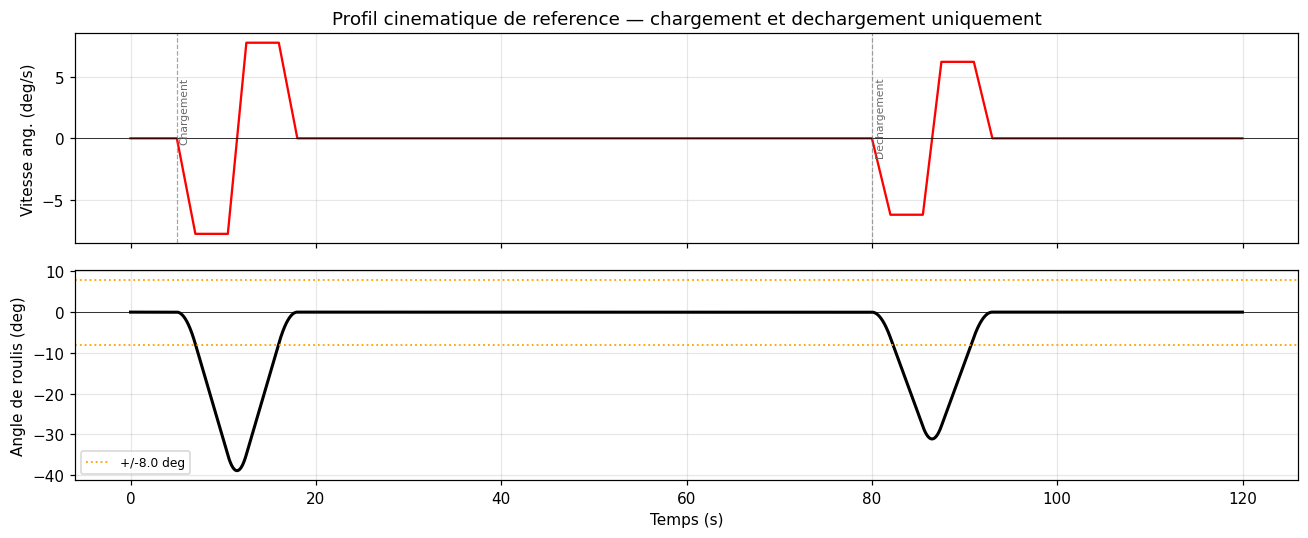

In [2]:
RAMP_T = 2.0   # s — duree des rampes (phases chargement/dechargement)

def loading_gx(t, t0, t1, angle_max, ramp_t):
    """Profil trapezodal de vitesse angulaire en 5 segments.
    Integrale totale = 0 : l'angle revient a zero en fin de phase."""
    D      = t1 - t0
    t_mid  = t0 + D / 2
    gx_max = abs(angle_max) / (D / 2 - ramp_t)
    s      = np.sign(angle_max)
    g      = np.zeros_like(t, dtype=float)

    m1 = (t >= t0)                & (t < t0 + ramp_t)
    m2 = (t >= t0 + ramp_t)       & (t < t_mid - ramp_t / 2)
    m3 = (t >= t_mid - ramp_t/2)  & (t < t_mid + ramp_t / 2)
    m4 = (t >= t_mid + ramp_t/2)  & (t < t1 - ramp_t)
    m5 = (t >= t1 - ramp_t)       & (t < t1)

    g[m1] =  s * gx_max * (t[m1] - t0) / ramp_t
    g[m2] =  s * gx_max
    g[m3] =  s * gx_max * (1.0 - 2.0 * (t[m3] - (t_mid - ramp_t/2)) / ramp_t)
    g[m4] = -s * gx_max
    g[m5] = -s * gx_max * (t1 - t[m5]) / ramp_t
    return g

# Le virage n'ajoute PAS de roulis reel : un vehicule qui tourne sur route plate
# lacet autour de l'axe vertical, gx (axe longitudinal) reste nul.
# La fausse alarme vient de l'accelerometre via l'acceleration centripete.
gx_true    = (loading_gx(t, T_CHARGE_DEB,  T_CHARGE_FIN,  -35.0, RAMP_T)
            + loading_gx(t, T_DECHARGE_DEB, T_DECHARGE_FIN, -28.0, RAMP_T))
theta_true = np.cumsum(gx_true) * Ts   # integration Euler

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
ax1.plot(t, gx_true, 'r-', lw=1.5)
ax1.axhline(0, color='k', lw=0.5)
ax1.set_ylabel('Vitesse ang. (deg/s)')
ax1.set_title('Profil cinematique de reference — chargement et dechargement uniquement')
ax1.grid(alpha=0.3)
for te, lbl in [(T_CHARGE_DEB, 'Chargement'), (T_DECHARGE_DEB, 'Dechargement')]:
    ax1.axvline(te, color='dimgrey', lw=0.8, ls='--', alpha=0.6)
    ax1.text(te + 0.3, 5, lbl, fontsize=7, color='dimgrey', rotation=90, va='top')

ax2.plot(t, theta_true, 'k-', lw=2.0)
ax2.axhline(0, color='k', lw=0.5)
ax2.axhline( SEUIL_ROLL, color='orange', ls=':', lw=1.2, label=f'+/-{SEUIL_ROLL} deg')
ax2.axhline(-SEUIL_ROLL, color='orange', ls=':', lw=1.2)
ax2.set_ylabel('Angle de roulis (deg)')
ax2.set_xlabel('Temps (s)')
ax2.legend(fontsize=8)
ax2.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Modèle d'accéléromètre

Quand la palette est inclinée d'un angle `theta` autour de l'axe X, la pesanteur se projette sur les axes Y et Z :
- `ay = g * sin(theta)`
- `az = g * cos(theta)`
- `ax = 0` (pas de mouvement selon X dans ce modèle)

On superpose deux sources de bruit **indépendantes**, combinées par somme quadratique :

| Source | Amplitude | Présente quand |
|--------|-----------|----------------|
| Bruit propre du capteur | 2 mg RMS | Toujours (électronique) |
| Vibrations de transport | 50 mg RMS | Roulage uniquement |

La somme quadratique `sigma_tot = sqrt(sigma_propre^2 + sigma_vib^2)` traduit l'indépendance statistique des deux sources.
Pendant les arrêts et la manutention, seul le bruit propre reste : 2 mg est trop faible pour être visible
à l'échelle du graphe (±0,8 g), ce qui est physiquement correct.

Acceleration centripete : 0.354 g
Angle apparent (arctan) : 19.5 deg


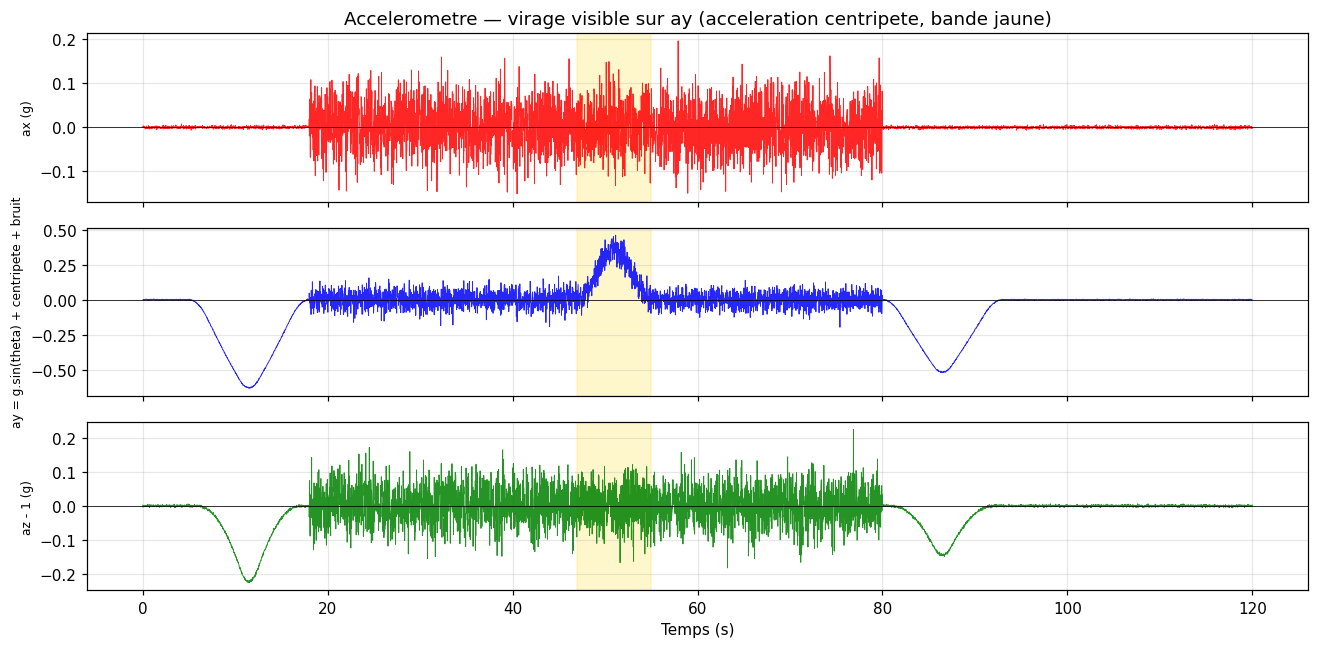

In [3]:
theta_rad = np.deg2rad(theta_true)
transport = (t >= T_TRANSPORT_DEB) & (t < T_TRANSPORT_FIN)

sig_vib = np.where(transport, SIGMA_ACC_VIBRATION, 0.0)
sig_tot = np.sqrt(SIGMA_ACC_PROPRE**2 + sig_vib**2)   # somme quadratique

ax_d = sig_tot * np.random.randn(N)
ay_d = np.sin(theta_rad) + sig_tot * np.random.randn(N)
az_d = np.cos(theta_rad) + sig_tot * np.random.randn(N)

# --- Acceleration centripete pendant le virage (fausse alarme accelerometre)
# Pendant un virage, le vehicule lacet (tourne autour de l'axe vertical) mais ne roule pas.
# L'accelerometre percoit la force centripete comme une inclinaison apparente.
# Pour un virage a 60 km/h (16,7 m/s) avec rayon R = 80 m :
V_VIRAGE  = 60.0 / 3.6   # m/s
R_VIRAGE  = 80.0          # m
A_CENTRIP = V_VIRAGE**2 / R_VIRAGE / 9.81   # g

print(f'Acceleration centripete : {A_CENTRIP:.3f} g')
print(f'Angle apparent (arctan) : {np.degrees(np.arctan(A_CENTRIP)):.1f} deg')

t_v0, D_v = T_VIRAGE_DEB, T_VIRAGE_FIN - T_VIRAGE_DEB
env_virage = np.where((t >= t_v0) & (t < t_v0 + D_v),
                      np.sin(np.pi * (t - t_v0) / D_v)**2, 0.0)
ay_d += A_CENTRIP * env_virage   # fausse alarme sur ay uniquement

fig, axes = plt.subplots(3, 1, figsize=(12, 6), sharex=True)
labels = ['ax (g)', 'ay = g.sin(theta) + centripete + bruit', 'az - 1 (g)']
data   = [ax_d, ay_d, az_d - 1.0]
colors = ['r', 'b', 'g']
for ax, d, lbl, col in zip(axes, data, labels, colors):
    ax.plot(t, d, color=col, lw=0.6, alpha=0.85)
    ax.axhline(0, color='k', lw=0.5)
    ax.set_ylabel(lbl, fontsize=8)
    ax.grid(alpha=0.3)
for ax in axes:
    ax.axvspan(t_v0, t_v0 + D_v, color='gold', alpha=0.2)
axes[0].set_title('Accelerometre — virage visible sur ay (acceleration centripete, bande jaune)')
axes[2].set_xlabel('Temps (s)')
plt.tight_layout()
plt.show()

## 3. Modèle de gyroscope

Le gyroscope mesure la vitesse angulaire de roulis `gx`. Deux imperfections sont modélisées :

- **Biais constant** `BIAIS_GX = 1,2 deg/s` : valeur typique pour l'ICM-20948 en fonctionnement.
  Intégré sur le temps, il produit une dérive linéaire de l'angle : 1,2 deg/s × 60 s = 72°.
- **Bruit blanc** de 3 mdeg/s RMS : bruit de mesure à haute fréquence, négligeable seul
  mais s'accumule à l'intégration (marche aléatoire).

L'axe `gx_d` (mesuré) est donc décalé de +1,2 deg/s par rapport à `gx_true` (réel).

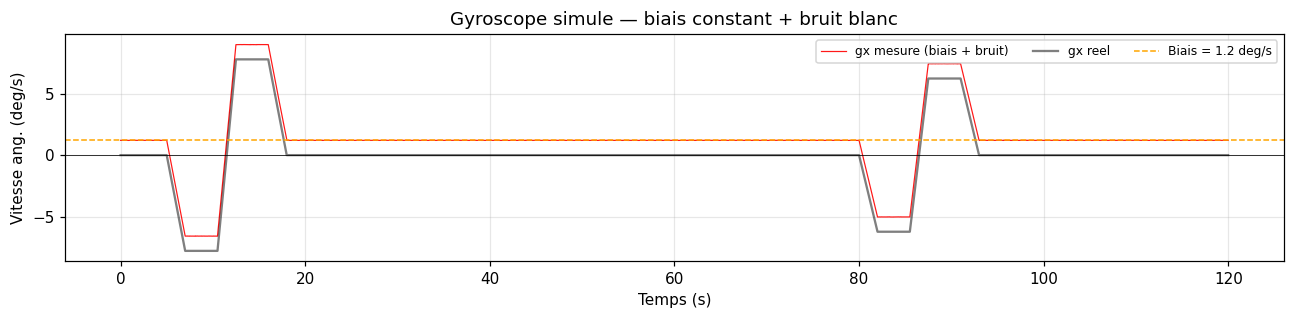

In [4]:
gx_d = gx_true + BIAIS_GX + SIGMA_GX * np.random.randn(N)
gy_d = SIGMA_GX * np.random.randn(N)   # axes Y et Z : bruit seul
gz_d = SIGMA_GX * np.random.randn(N)

fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(t, gx_d,   'r-', lw=0.8, alpha=0.9, label='gx mesure (biais + bruit)')
ax.plot(t, gx_true,'k-', lw=1.5, alpha=0.5, label='gx reel')
ax.axhline(BIAIS_GX, color='orange', ls='--', lw=1.0,
           label=f'Biais = {BIAIS_GX} deg/s')
ax.axhline(0, color='k', lw=0.5)
ax.set_ylabel('Vitesse ang. (deg/s)')
ax.set_xlabel('Temps (s)')
ax.set_title('Gyroscope simule — biais constant + bruit blanc')
ax.legend(fontsize=8, ncol=3)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Filtre complémentaire

Ni l'accéléromètre seul ni le gyroscope seul ne donnent une estimation fiable de l'angle :

| Source | Avantage | Limite |
|--------|----------|--------|
| Accéléromètre | Pas de dérive (recalage par la pesanteur) | Bruité, perturbé en dynamique |
| Gyroscope | Suivi dynamique précis à court terme | Dérive linéaire due au biais |

Le filtre complémentaire fusionne les deux en pondérant selon la fréquence :
- Basse fréquence (lentes variations, drift) : on fait confiance à l'accéléromètre
- Haute fréquence (changements rapides) : on fait confiance au gyroscope

La constante de temps du filtre est `tau = alpha * Ts / (1 - alpha)` :
avec `alpha = 0,98` et `Ts = 0,02 s`, on obtient `tau ≈ 1 s`.
Les perturbations d'accélération de durée inférieure à 1 s (virages, freinages) sont rejetées.

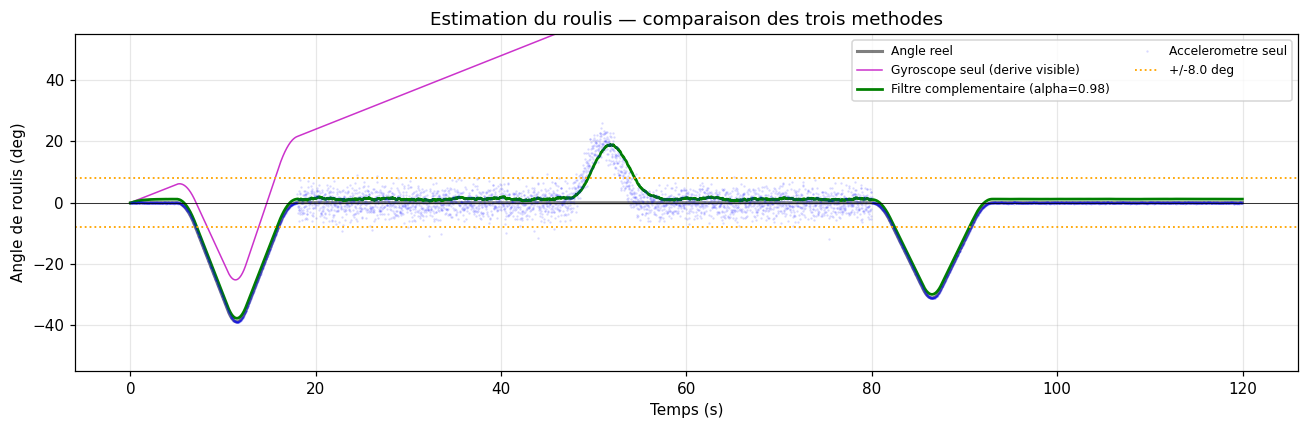

In [5]:
# Estimation par accéléromètre seul (atan2)
roll_acc = np.degrees(np.arctan2(ay_d, az_d))

# Estimation par gyroscope seul (intégration d'Euler — dérive visible)
roll_gyro = np.zeros(N)
for k in range(1, N):
    roll_gyro[k] = roll_gyro[k-1] + gx_d[k] * Ts

# Filtre complémentaire
roll_filt = np.zeros(N)
roll_filt[0] = roll_acc[0]
for k in range(1, N):
    roll_filt[k] = alpha * (roll_filt[k-1] + gx_d[k] * Ts) + (1 - alpha) * roll_acc[k]

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(t, theta_true, 'k-',  lw=2.0, alpha=0.5, label='Angle reel')
ax.plot(t, roll_gyro,  'm-',  lw=1.0, alpha=0.8, label='Gyroscope seul (derive visible)')
ax.plot(t, roll_filt,  'g-',  lw=1.8,             label=f'Filtre complementaire (alpha={alpha})')
ax.plot(t, roll_acc,   'b.',  ms=1,   alpha=0.15, label='Accelerometre seul')
ax.axhline( SEUIL_ROLL, color='orange', ls=':', lw=1.2, label=f'+/-{SEUIL_ROLL} deg')
ax.axhline(-SEUIL_ROLL, color='orange', ls=':', lw=1.2)
ax.axhline(0, color='k', lw=0.5)
ax.set_ylabel('Angle de roulis (deg)')
ax.set_xlabel('Temps (s)')
ax.set_title('Estimation du roulis — comparaison des trois methodes')
ax.set_ylim([-55, 55])
ax.legend(fontsize=8, ncol=2)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Détection d'arrêt par écart-type glissant

Pour détecter si le véhicule est à l'arrêt, on exploite le fait que la norme du vecteur accélération
vaut toujours environ 1 g en l'absence de mouvement dynamique (seule la pesanteur contribue).
Pendant le roulage, les vibrations de la route font fluctuer cette norme autour de 1 g.

**Indicateur d'agitation :** dérivée discrète de la norme, puis écart-type sur fenêtre glissante causale de 1 s :
- A l'arrêt : norme quasi constante → dérivée ≈ 0 → sigma ≈ 0
- En roulage : vibrations → sigma élevé

**Valeurs théoriques** (bruit blanc gaussien, fenêtre rectangulaire) :

| Phase | sigma théorique |
|-------|----------------|
| Arrêt (bruit propre 2 mg) | sqrt(2) × 0,002 / 0,02 ≈ **0,14 g/s** |
| Roulage (vibrations 50 mg) | sqrt(2) × 0,050 / 0,02 ≈ **3,5 g/s** |

Le seuil est calé entre les deux : **1,5 g/s** offre une marge ×10 au-dessus de l'arrêt et ×2,4
en dessous du roulage. En pratique, ce seuil serait déterminé par calibration sur des données réelles
(quelques trajets représentatifs suffisent : l'écart de deux décades rend le choix peu critique).

**Lien avec la méthode de Welch :** les deux sont des estimateurs locaux d'énergie sur fenêtre temporelle.
Welch conserve la décomposition fréquentielle (DSP), sigma la résume en un seul nombre.
La fenêtre rectangulaire ici équivaut au cas non pondéré de Welch.

La première seconde (fenêtre incomplète) est masquée et traitée comme un arrêt par défaut.

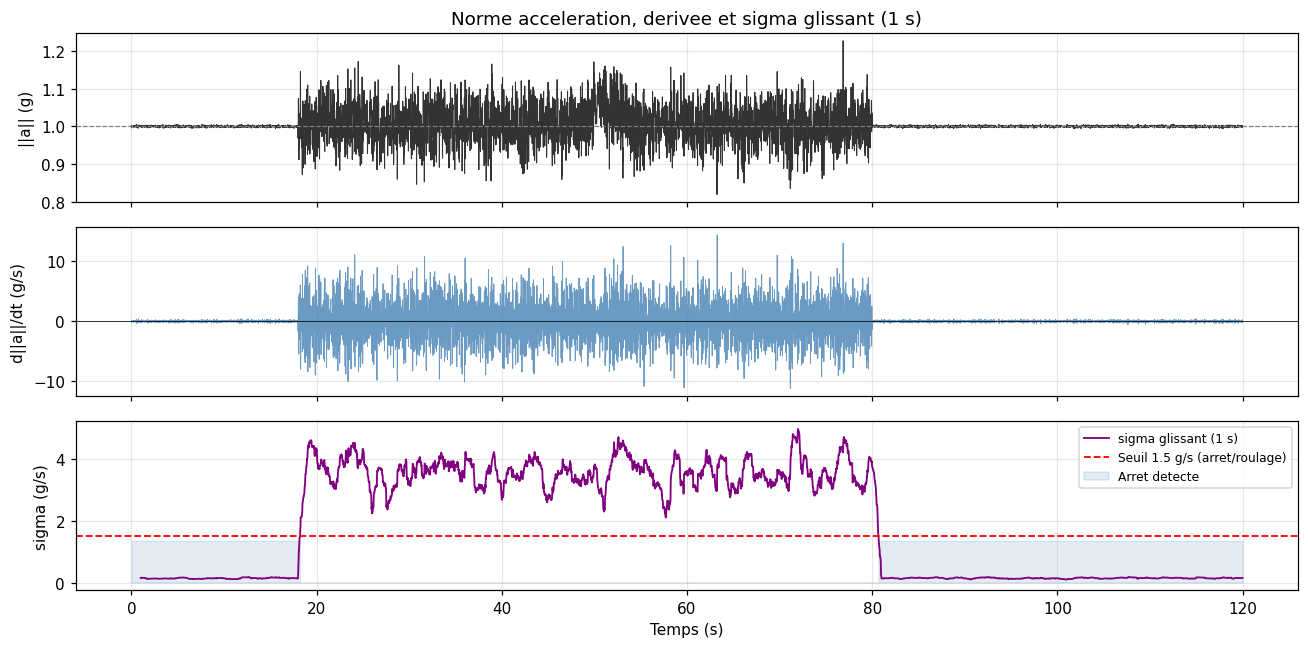

Taux de detection arret : 47.9 % du temps


In [6]:
def causal_std(x, w):
    """Ecart-type glissant causal sur w echantillons (fenetre rectangulaire)."""
    pad = np.concatenate([np.repeat(x[0], w - 1), x])
    m1  = np.convolve(pad, np.ones(w) / w, mode='valid')
    m2  = np.convolve(pad**2, np.ones(w) / w, mode='valid')
    return np.sqrt(np.maximum(0.0, m2 - m1**2))

win   = int(WIN_S * fs)                    # 50 echantillons = 1 s
a_norm = np.sqrt(ax_d**2 + ay_d**2 + az_d**2)
da     = np.concatenate([[0.0], np.diff(a_norm)]) / Ts   # derivee discrete

da_std       = causal_std(da, win)
da_std[:win] = np.nan    # premiere fenetre incomplete — masquee

det_arret = np.where(np.isnan(da_std), True, da_std < SEUIL_DA)

fig, axes = plt.subplots(3, 1, figsize=(12, 6), sharex=True)

axes[0].plot(t, a_norm, 'k-', lw=0.7, alpha=0.8)
axes[0].axhline(1.0, color='gray', ls='--', lw=0.8)
axes[0].set_ylabel('||a|| (g)')
axes[0].set_title('Norme acceleration, derivee et sigma glissant (1 s)')
axes[0].grid(alpha=0.3)

axes[1].plot(t, da, color='steelblue', lw=0.6, alpha=0.8)
axes[1].axhline(0, color='k', lw=0.5)
axes[1].set_ylabel('d||a||/dt (g/s)')
axes[1].grid(alpha=0.3)

axes[2].plot(t, da_std, color='purple', lw=1.2, label='sigma glissant (1 s)')
axes[2].axhline(SEUIL_DA, color='red', ls='--', lw=1.2,
                label=f'Seuil {SEUIL_DA} g/s (arret/roulage)')
axes[2].fill_between(t, 0, det_arret.astype(float) * SEUIL_DA * 0.9,
                     color='steelblue', alpha=0.15, label='Arret detecte')
axes[2].set_ylabel('sigma (g/s)')
axes[2].set_xlabel('Temps (s)')
axes[2].legend(fontsize=8)
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

pct_arret = det_arret.mean() * 100
print(f'Taux de detection arret : {pct_arret:.1f} % du temps')

## 6. Logique de détection finale

La détection repose sur une **condition double** : angle > 8° ET véhicule à l'arrêt.

**Pourquoi la double condition est nécessaire — mécanisme physique du virage :**

Pendant un virage, le véhicule lacet (rotation autour de l'axe vertical Z) mais ne roule pas
(gx ≈ 0). L'accéléromètre perçoit l'accélération centripète v²/R sur l'axe Y,
qu'il ne peut pas distinguer d'une inclinaison réelle.
À 60 km/h / R = 80 m : a_centripète ≈ 0,35 g → angle apparent ≈ 19°, bien au-dessus du seuil de 8°.

Avec alpha = 0,98 (tau ≈ 1 s), le filtre complémentaire est lui aussi partiellement trompé
via le terme (1 − alpha) × roll_acc : si le virage dure plusieurs constantes de temps,
roll_filt converge progressivement vers la lecture accéléromètre (ici ~19°).
La condition de roulis seule déclencherait donc une **fausse détection**.

Mais le véhicule est en mouvement pendant le virage : sigma reste élevé (~3,5 g/s),
la condition d'arrêt est False, et det_charge reste à zéro. La double condition est indispensable.

Un filtre d'hystérésis (2 s) lisse les transitions ; la condition d'arrêt est dilatée
de 3 s de chaque côté pour absorber un léger mouvement résiduel en début/fin de manutention.

In [7]:
def detect_hysteresis(raw, hyst_samples, n):
    """Filtre d'hysteresis : maintient l'etat True tant qu'il ne s'est
    pas ecoule hyst_samples echantillons consecutifs a False."""
    det, state = np.zeros(n, dtype=bool), False
    for k in range(n):
        if raw[k]:
            state = True
        elif state and not np.any(raw[k:min(k + hyst_samples, n)]):
            state = False
        det[k] = state
    return det

HYST      = int(2.0 * fs)    # 2 s d'hysteresis
DIL_WIN   = int(3.0 / Ts)    # dilatation 3 s

# Detection roulis avec hysteresis
raw_incl = np.abs(roll_filt) > SEUIL_ROLL
det_incl = detect_hysteresis(raw_incl, HYST, N)

# Dilatation de la condition d'arret
kernel       = np.ones(2 * DIL_WIN + 1)
arret_dilate = np.convolve(det_arret.astype(float), kernel, mode='same') > 0

# Detection finale : roulis ET arret
det_charge = detect_hysteresis(det_incl & arret_dilate, HYST, N)

# Verification : phases reelles
charge_reel   = (t >= T_CHARGE_DEB)   & (t < T_CHARGE_FIN)
decharge_reel = (t >= T_DECHARGE_DEB) & (t < T_DECHARGE_FIN)
manut_reel    = charge_reel | decharge_reel

vp = ( det_charge &  manut_reel).sum()   # vrais positifs
fp = ( det_charge & ~manut_reel).sum()   # fausses alarmes
fn = (~det_charge &  manut_reel).sum()   # manques
print(f'Vrais positifs  : {vp/fs:.1f} s  ({100*vp/manut_reel.sum():.0f} % des phases reelles)')
print(f'Fausses alarmes : {fp/fs:.1f} s')
print(f'Manques         : {fn/fs:.1f} s')

Vrais positifs  : 16.7 s  (64 % des phases reelles)
Fausses alarmes : 0.0 s
Manques         : 9.3 s


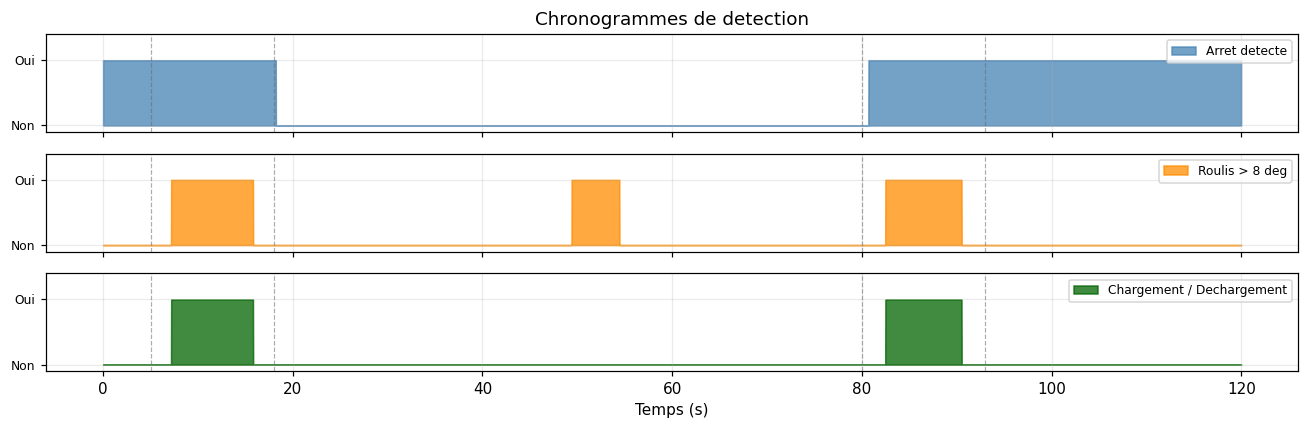

In [8]:
EVENTS = [
    (T_CHARGE_DEB,   'Chargement'),
    (T_TRANSPORT_DEB, 'Debut transport'),
    (T_DECHARGE_DEB, 'Arret / Dechargement'),
    (T_DECHARGE_FIN, 'Fin dechargement'),
]

fig, axes = plt.subplots(3, 1, figsize=(12, 4), sharex=True)
chrono_data = [
    (det_arret,   'steelblue',  'Arret detecte'),
    (det_incl,    'darkorange', f'Roulis > {SEUIL_ROLL:.0f} deg'),
    (det_charge,  'darkgreen',  'Chargement / Dechargement'),
]
for ax, (sig, col, lbl) in zip(axes, chrono_data):
    ax.fill_between(t, sig.astype(float), 0, color=col, alpha=0.75, label=lbl)
    for te, txt in EVENTS:
        ax.axvline(te, color='dimgrey', lw=0.8, ls='--', alpha=0.55)
    ax.set_ylim([-0.1, 1.4])
    ax.set_yticks([0, 1])
    ax.set_yticklabels(['Non', 'Oui'], fontsize=8)
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(alpha=0.25)

axes[2].set_xlabel('Temps (s)')
axes[0].set_title('Chronogrammes de detection')
plt.tight_layout()
plt.show()

## 7. Figure de synthèse

La figure ci-dessous rassemble les sept sous-graphes : données brutes (gyroscope, accéléromètre),
traitement (roulis estimé, sigma), et chronogrammes de détection.
C'est cette figure qui est reproduite dans le dossier industriel.

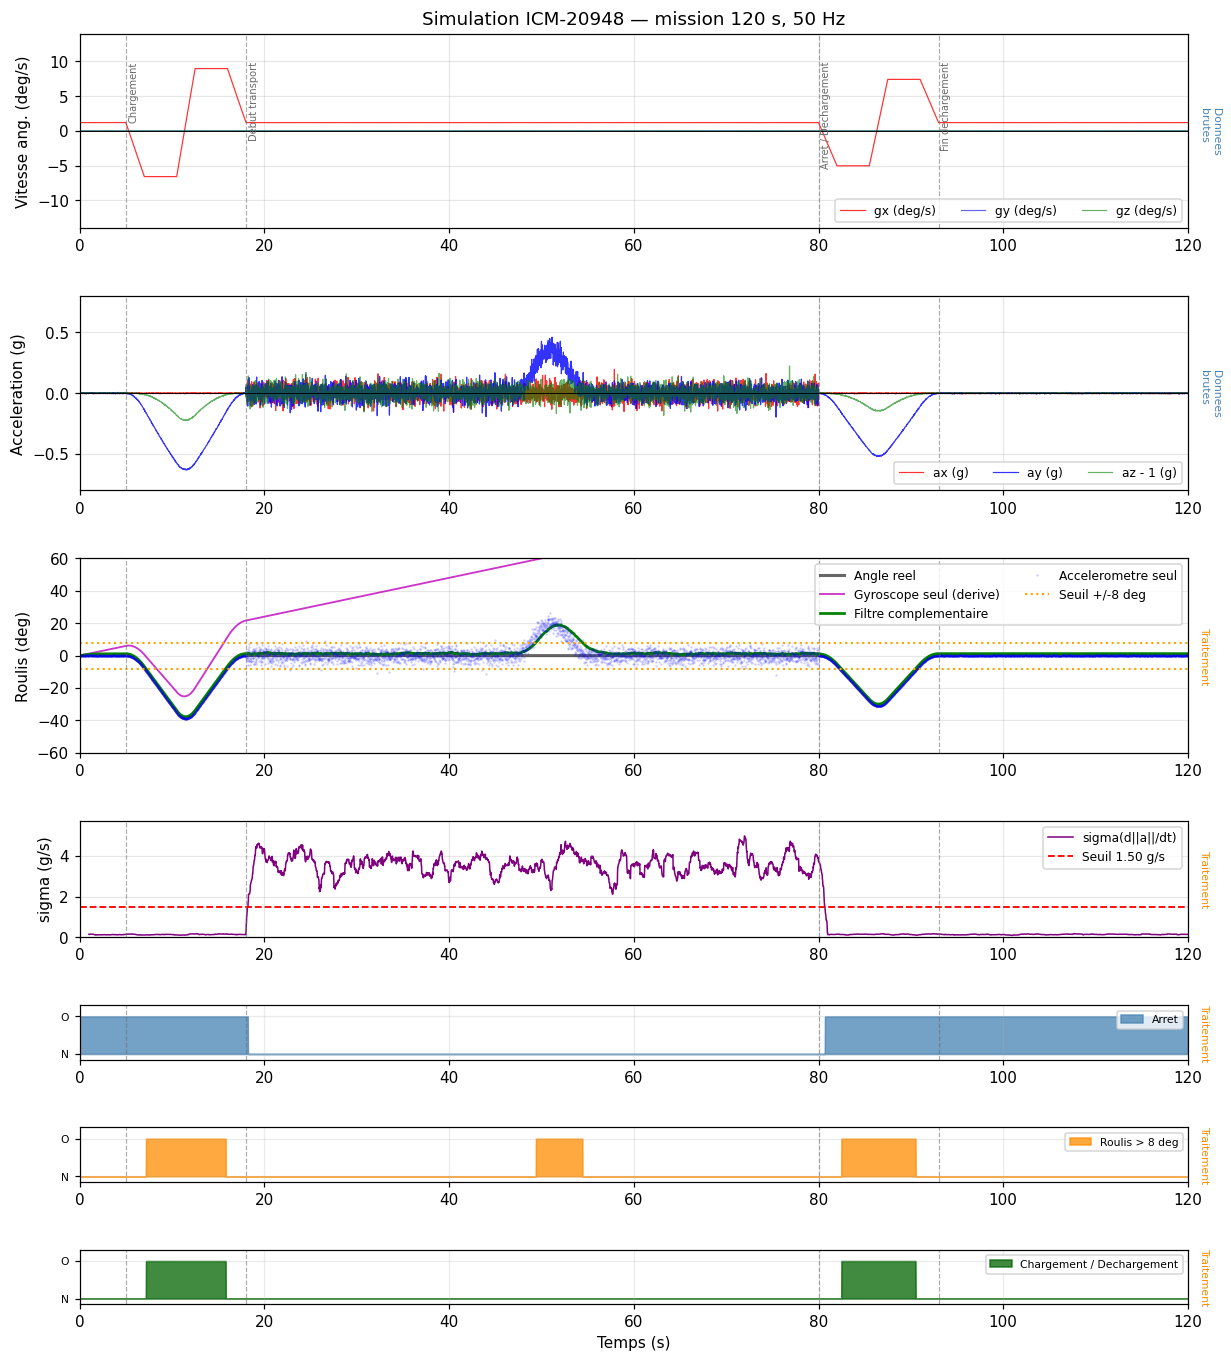

In [9]:
from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(13, 15))
gs  = GridSpec(7, 1, hspace=0.55,
               height_ratios=[2.5, 2.5, 2.5, 1.5, 0.7, 0.7, 0.7], figure=fig)

def add_vlines(ax, annotate=False, ytext=None):
    for te, label in EVENTS:
        ax.axvline(te, color='dimgrey', lw=0.8, ls='--', alpha=0.55)
    if annotate and ytext is not None:
        for te, label in EVENTS:
            ax.text(te + 0.3, ytext, label, fontsize=6.5, color='dimgrey',
                    rotation=90, va='top')

ax1 = fig.add_subplot(gs[0])
ax1.plot(t, gx_d, 'r-', lw=0.8, alpha=0.8, label='gx (deg/s)')
ax1.plot(t, gy_d, 'b-', lw=0.8, alpha=0.6, label='gy (deg/s)')
ax1.plot(t, gz_d, 'g-', lw=0.8, alpha=0.6, label='gz (deg/s)')
ax1.axhline(0, color='k', lw=0.6)
add_vlines(ax1, annotate=True, ytext=10)
ax1.set_ylabel('Vitesse ang. (deg/s)')
ax1.set_title('Simulation ICM-20948 — mission 120 s, 50 Hz')
ax1.legend(fontsize=8, ncol=3, loc='lower right')
ax1.set_xlim([0, T]); ax1.set_ylim([-14, 14]); ax1.grid(True, alpha=0.30)

ax2 = fig.add_subplot(gs[1], sharex=ax1)
ax2.plot(t, ax_d,       'r-', lw=0.8, alpha=0.8, label='ax (g)')
ax2.plot(t, ay_d,       'b-', lw=0.8, alpha=0.8, label='ay (g)')
ax2.plot(t, az_d - 1.0, 'g-', lw=0.8, alpha=0.6, label='az - 1 (g)')
ax2.axhline(0, color='k', lw=0.6)
add_vlines(ax2)
ax2.set_ylabel('Acceleration (g)')
ax2.legend(fontsize=8, ncol=3, loc='lower right')
ax2.set_ylim([-0.8, 0.8]); ax2.grid(True, alpha=0.30)

ax3 = fig.add_subplot(gs[2], sharex=ax1)
ax3.plot(t, theta_true, 'k-',  lw=2.0, alpha=0.6, label='Angle reel')
ax3.plot(t, roll_gyro,  'm-',  lw=1.2, alpha=0.8, label='Gyroscope seul (derive)')
ax3.plot(t, roll_filt,  'g-',  lw=1.8,             label='Filtre complementaire')
ax3.plot(t, roll_acc,   'b.',  ms=1, alpha=0.20,   label='Accelerometre seul')
ax3.axhline( SEUIL_ROLL, color='orange', ls=':', lw=1.4,
             label=f'Seuil +/-{SEUIL_ROLL:.0f} deg')
ax3.axhline(-SEUIL_ROLL, color='orange', ls=':', lw=1.4)
add_vlines(ax3)
ax3.set_ylabel('Roulis (deg)')
ax3.set_ylim([-60, 60])
ax3.legend(fontsize=8, ncol=2, loc='upper right')
ax3.grid(True, alpha=0.30)

ax_da = fig.add_subplot(gs[3], sharex=ax1)
ax_da.plot(t, da_std, color='purple', lw=1.0, label='sigma(d||a||/dt)')
ax_da.axhline(SEUIL_DA, color='red', ls='--', lw=1.2,
              label=f'Seuil {SEUIL_DA:.2f} g/s')
add_vlines(ax_da)
ax_da.set_ylabel('sigma (g/s)')
ax_da.set_ylim([0, max(np.nanmax(da_std) * 1.15, SEUIL_DA * 1.5)])
ax_da.legend(fontsize=8, loc='upper right')
ax_da.grid(True, alpha=0.30); ax_da.set_xlim([0, T])

def chrono_fill(ax, signal, color, label):
    ax.fill_between(t, signal.astype(float), 0, color=color, alpha=0.75, label=label)
    add_vlines(ax)
    ax.set_ylim([-0.15, 1.3])
    ax.set_yticks([0, 1]); ax.set_yticklabels(['N', 'O'], fontsize=7)
    ax.legend(fontsize=7, loc='upper right')
    ax.grid(True, alpha=0.25); ax.set_xlim([0, T])

ax4 = fig.add_subplot(gs[4], sharex=ax1)
chrono_fill(ax4, det_arret,  'steelblue',  'Arret')
ax5 = fig.add_subplot(gs[5], sharex=ax1)
chrono_fill(ax5, det_incl,   'darkorange', f'Roulis > {SEUIL_ROLL:.0f} deg')
ax6 = fig.add_subplot(gs[6], sharex=ax1)
chrono_fill(ax6, det_charge, 'darkgreen',  'Chargement / Dechargement')
ax6.set_xlabel('Temps (s)')

for ax, label, color in [
    (ax1, 'Donnees\nbrutes', 'steelblue'), (ax2, 'Donnees\nbrutes', 'steelblue'),
    (ax3, 'Traitement', 'darkorange'),     (ax_da, 'Traitement', 'darkorange'),
    (ax4, 'Traitement', 'darkorange'),     (ax5, 'Traitement', 'darkorange'),
    (ax6, 'Traitement', 'darkorange'),
]:
    ax.annotate(label, xy=(1.01, 0.5), xycoords='axes fraction',
                va='center', ha='left', fontsize=7, color=color,
                rotation=-90, annotation_clip=False)

plt.show()

## 8. Validation expérimentale — données réelles ICM-20948

Essai terrain : ICM-20948 sur ESP32C3 (50 Hz, 120 s), fixé sur support rigide.
Protocole : inclinaison manuelle en début et fin de trajet pour simuler la manutention,
trajet routier réel (accélérations, freinages, virages, route dégradée).

Les données sont dans `data_icm.csv` (colonnes : `t_ms, ax, ay, az, gx, gy, gz, roll_acc, roll_filt`).
La colonne `roll_filt` a été calculée par l'ESP32 avec α=0,98 ; on recalcule ici les 3 valeurs depuis les données brutes.

In [ ]:

# Chargement des donnees experimentales et calcul des 3 filtres
import pandas as pd

df_exp      = pd.read_csv('data_icm.csv')
t_exp       = df_exp['t_ms'].values / 1000.0
ax_e, ay_e, az_e = df_exp['ax'].values, df_exp['ay'].values, df_exp['az'].values
gx_e        = df_exp['gx'].values   # deg/s
gy_e        = df_exp['gy'].values
gz_e        = df_exp['gz'].values
roll_acc_e  = df_exp['roll_acc'].values   # arctan2(ay, az) en degres

N_e   = len(t_exp)
Te_e  = np.median(np.diff(t_exp))   # pas de temps median
T_e   = t_exp[-1]
win_e = int(1.0 / Te_e)

print(f'Donnees : {N_e} echantillons, {T_e:.1f} s, Te median = {Te_e*1000:.1f} ms')

# Evenements video (repris de trace_essai_reel.py — ancien dossier)
EVENTS_EXP = [
    ( 5.2,  '1re inclinaison'),
    (10.5,  'Demarrage'),
    (20.0,  'Acceleration brusque'),
    (22.8,  'Freinage brusque'),
    (30.9,  'Serie de virages'),
    (57.0,  'Ligne droite'),
    (65.3,  "Montee dos-d'ane"),
    (71.6,  "Descente dos-d'ane"),
    (81.0,  'Chemin'),
    (88.1,  'Passage rigole'),
    (97.5,  'Arret'),
    (102.9, '2e inclinaison'),
]

def add_vlines_exp(ax, annotate=False, ytext=None):
    for te, label in EVENTS_EXP:
        ax.axvline(te, color='dimgrey', lw=0.8, ls='--', alpha=0.55)
    if annotate and ytext is not None:
        for te, label in EVENTS_EXP:
            ax.text(te + 0.3, ytext, label,
                    fontsize=6, color='dimgrey', rotation=90, va='top')

# Filtre complementaire — initialise a roll_acc[0], dt reel (comme trace_essai_reel_split.py)
def comp_filter_e(roll_acc, gx_dps, t_vec, alpha):
    phi = np.zeros(len(roll_acc))
    phi[0] = roll_acc[0]
    for k in range(1, len(roll_acc)):
        phi[k] = alpha * (phi[k-1] + gx_dps[k] * (t_vec[k] - t_vec[k-1])) + (1 - alpha) * roll_acc[k]
    return phi

roll_98_e  = comp_filter_e(roll_acc_e, gx_e, t_exp, 0.980)
roll_999_e = comp_filter_e(roll_acc_e, gx_e, t_exp, 0.999)
roll_995_e = comp_filter_e(roll_acc_e, gx_e, t_exp, 0.995)

# Donnees brutes : gx (roulis), gz (lacet), gy (tangage) + ax/ay/az
GY_LIM = 65.0   # deg/s

fig_r, (axr1, axr2) = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

axr1.plot(t_exp, gx_e, 'r-',              lw=0.8, alpha=0.85, label='gx — roulis (deg/s)')
axr1.plot(t_exp, gz_e, color='steelblue', lw=0.9, alpha=0.85, label='gz — lacet (deg/s)')
axr1.plot(t_exp, gy_e, color='gray',      lw=0.6, alpha=0.60, label='gy — tangage (deg/s)')
axr1.axhline(0, color='k', lw=0.6)
add_vlines_exp(axr1, annotate=True, ytext=GY_LIM * 0.82)
axr1.set_ylabel('Vitesse ang. (deg/s)')
axr1.set_title('Essai terrain ICM-20948 — 120 s, 50 Hz — donnees brutes')
axr1.legend(fontsize=7.5, ncol=3, loc='lower right')
axr1.set_xlim([0, T_e])
axr1.set_ylim([-GY_LIM, GY_LIM])
axr1.grid(alpha=0.30)

axr2.plot(t_exp, ax_e,        'r-', lw=0.8, alpha=0.8, label='ax (g)')
axr2.plot(t_exp, ay_e,        'b-', lw=0.8, alpha=0.8, label='ay (g)')
axr2.plot(t_exp, az_e - 1.0,  'g-', lw=0.8, alpha=0.6, label='az - 1 (g)')
axr2.axhline(0, color='k', lw=0.6)
add_vlines_exp(axr2)
axr2.set_ylabel('Acceleration (g)')
axr2.set_xlabel('Temps (s)')
axr2.legend(fontsize=8, ncol=3, loc='lower right')
axr2.set_ylim([-1.0, 1.0])
axr2.grid(alpha=0.30)

plt.tight_layout()
plt.show()


In [ ]:

# Comparaison des 3 valeurs de alpha sur donnees reelles — 6 panneaux (roulis + chrono par alpha)
# Logique et couleurs reprises de trace_essai_reel_split.py (ancien dossier)
from matplotlib.gridspec import GridSpec as _GS

ALPHAS_EXP   = [0.98,      0.999,   0.995]
COLORS_EXP   = ['limegreen', 'tomato', 'dodgerblue']
ROLLS_EXP    = [roll_98_e,  roll_999_e, roll_995_e]
SEUIL_ROLL_E = 8.0
HYST_EXP     = int(2.0 / Te_e)

def detect_hyst_e(raw, hyst, n):
    det, state = np.zeros(n, dtype=bool), False
    for k in range(n):
        if raw[k]:
            state = True
        elif state and not np.any(raw[k:min(k + hyst, n)]):
            state = False
        det[k] = state
    return det

fig_a = plt.figure(figsize=(13, 14))
gs_a  = _GS(6, 1, hspace=0.45,
             height_ratios=[2.5, 0.7, 2.5, 0.7, 2.5, 0.7],
             figure=fig_a)

for i, (alpha, color, rf) in enumerate(zip(ALPHAS_EXP, COLORS_EXP, ROLLS_EXP)):
    raw_incl = np.abs(rf) > SEUIL_ROLL_E

    ax_r = fig_a.add_subplot(gs_a[i * 2])
    ax_r.plot(t_exp, roll_acc_e, color='deepskyblue', lw=0.8, alpha=0.6, label='Accelerometre seul')
    ax_r.plot(t_exp, rf, color=color, lw=0.8, label=f'Filtre complementaire (alpha={alpha})')
    ax_r.axhline( SEUIL_ROLL_E, color='orange', ls=':', lw=1.2, label=f'Seuil +/-{SEUIL_ROLL_E:.0f} deg')
    ax_r.axhline(-SEUIL_ROLL_E, color='orange', ls=':', lw=1.2)
    add_vlines_exp(ax_r)
    ax_r.set_ylabel('Roulis (deg)')
    ax_r.set_ylim([-60, 60])
    ax_r.legend(fontsize=8, ncol=3, loc='upper right')
    ax_r.grid(alpha=0.30)
    ax_r.set_xlim([0, T_e])
    if i == 0:
        ax_r.set_title('Traitement — comparaison des trois valeurs de alpha')

    ax_c = fig_a.add_subplot(gs_a[i * 2 + 1], sharex=ax_r)
    ax_c.fill_between(t_exp, raw_incl.astype(float), 0, color=color, alpha=0.75,
                      label=f'|roulis| > {SEUIL_ROLL_E:.0f} deg  (alpha={alpha})')
    add_vlines_exp(ax_c)
    ax_c.set_ylim([-0.15, 1.3])
    ax_c.set_yticks([0, 1]); ax_c.set_yticklabels(['N', 'O'], fontsize=7)
    ax_c.legend(fontsize=7, loc='upper right')
    ax_c.grid(alpha=0.25); ax_c.set_xlim([0, T_e])

plt.tight_layout()
plt.show()


In [ ]:

# Detection sur donnees reelles — seuil 0.20 g/s et duree minimale 0.5 s
# (repris de trace_essai_reel_split.py, SEUIL_DA=0.20, MIN_DUR=0.5 s)
SEUIL_DA_EXP = 0.20   # g/s — seuil experimental (plus bas qu'en simulation)
MIN_DUR_E    = int(0.5 / Te_e)

a_norm_e = np.sqrt(ax_e**2 + ay_e**2 + az_e**2)
da_e     = np.concatenate([[0.0], np.diff(a_norm_e)]) / Te_e   # g/s

da_std_e  = causal_std(da_e, win_e)
raw_const = da_std_e < SEUIL_DA_EXP

# Filtrage par duree minimale (periode silencieuse >= MIN_DUR echantillons)
changes = np.diff(raw_const.astype(int))
starts  = list(np.where(changes == 1)[0] + 1)
ends    = list(np.where(changes == -1)[0] + 1)
if raw_const[0]:   starts = [0] + starts
if raw_const[-1]:  ends   = ends + [N_e]
periodes_const = [(s, e) for s, e in zip(starts, ends) if (e - s) >= MIN_DUR_E]
det_arret_e = np.zeros(N_e, dtype=bool)
for s, e in periodes_const:
    det_arret_e[s:e] = True

HYST_E    = int(2.0 / Te_e)
raw_incl_e   = np.abs(roll_98_e) > SEUIL_ROLL_E
det_incl_e   = detect_hyst_e(raw_incl_e, HYST_E, N_e)

dil_e        = int(3.0 / Te_e)
kernel_e     = np.ones(2 * dil_e + 1)
arret_dil_e  = np.convolve(det_arret_e.astype(float), kernel_e, mode='same') > 0
det_charge_e = detect_hyst_e(det_incl_e & arret_dil_e, HYST_E, N_e)

print(f'Detecte a l arret : {det_arret_e.mean()*100:.1f} % du temps')
print(f'Detecte roulis    : {det_incl_e.mean()*100:.1f} % du temps')
print(f'Detecte manut.    : {det_charge_e.mean()*100:.1f} % du temps')


In [ ]:

# Figure de synthese — essai terrain (sigma en echelle log, comme trace_essai_reel_split.py)
from matplotlib.gridspec import GridSpec as _GS2

fig_e = plt.figure(figsize=(13, 10))
gs_e  = _GS2(4, 1, hspace=0.55,
              height_ratios=[2.5, 1.5, 0.7, 0.7], figure=fig_e)

ax_e1 = fig_e.add_subplot(gs_e[0])
ax_e1.plot(t_exp, roll_98_e,  color='limegreen', lw=1.8, label='Filtre complementaire (alpha=0.98)')
ax_e1.plot(t_exp, roll_acc_e, color='deepskyblue', lw=0.8, alpha=0.5, label='Accelerometre seul')
ax_e1.axhline( SEUIL_ROLL_E, color='orange', ls=':', lw=1.4, label=f'+/-{SEUIL_ROLL_E:.0f} deg')
ax_e1.axhline(-SEUIL_ROLL_E, color='orange', ls=':', lw=1.4)
add_vlines_exp(ax_e1, annotate=True, ytext=50)
ax_e1.set_ylabel('Roulis (deg)'); ax_e1.set_ylim([-60, 60])
ax_e1.set_title('Essai terrain ICM-20948 — detection (alpha=0.98, seuil sigma=0.20 g/s)')
ax_e1.legend(fontsize=8, ncol=2, loc='upper right')
ax_e1.grid(alpha=0.30); ax_e1.set_xlim([0, T_e])

ax_e2 = fig_e.add_subplot(gs_e[1], sharex=ax_e1)
ax_e2.semilogy(t_exp, da_std_e + 1e-6, color='purple', lw=1.0, label='sigma(d||a||/dt)')
ax_e2.axhline(SEUIL_DA_EXP, color='red', ls='--', lw=1.2, label=f'Seuil {SEUIL_DA_EXP:.2f} g/s')
add_vlines_exp(ax_e2)
ax_e2.set_ylabel('sigma (g/s)')
ax_e2.legend(fontsize=8, loc='upper right')
ax_e2.grid(alpha=0.30, which='both'); ax_e2.set_xlim([0, T_e])

def chrono_e(ax, sig, col, lbl):
    ax.fill_between(t_exp, sig.astype(float), 0, color=col, alpha=0.75, label=lbl)
    add_vlines_exp(ax)
    ax.set_ylim([-0.15, 1.3]); ax.set_yticks([0, 1])
    ax.set_yticklabels(['N', 'O'], fontsize=7)
    ax.legend(fontsize=7, loc='upper right'); ax.grid(alpha=0.25); ax.set_xlim([0, T_e])

ax_e3 = fig_e.add_subplot(gs_e[2], sharex=ax_e1)
chrono_e(ax_e3, det_arret_e,  'steelblue', 'Arret detecte')
ax_e4 = fig_e.add_subplot(gs_e[3], sharex=ax_e1)
chrono_e(ax_e4, det_charge_e, 'darkgreen', 'Chargement / Dechargement (roulis + arret)')
ax_e4.set_xlabel('Temps (s)')

plt.tight_layout()
plt.show()


In [ ]:

# --- Resume des resultats
n_phases_det = 0
starts = np.where(np.diff(det_charge_e.astype(int)) == 1)[0]
ends   = np.where(np.diff(det_charge_e.astype(int)) == -1)[0]
if det_charge_e[0]:
    starts = np.concatenate([[0], starts])
if det_charge_e[-1]:
    ends = np.concatenate([ends, [N_e - 1]])
n_phases_det = len(starts)
print(f'Phases de manutention detectees : {n_phases_det}')
for i, (s, e) in enumerate(zip(starts, ends)):
    print(f'  Phase {i+1} : {t_exp[s]:.1f} s -> {t_exp[e]:.1f} s  (duree {t_exp[e]-t_exp[s]:.1f} s)')

fp_e = (det_charge_e & ~np.zeros(N_e, dtype=bool)).sum()  # placeholder
print(f'Fausses alarmes pendant le trajet : a verifier sur la figure')
